# **YOLOV1 plots explanation**

In [ ]:
from pathlib import Path

import os
import sys
import matplotlib.pyplot as plt

path = Path.cwd()
while not (path / "computer_vision").exists():
    path = path.parent

sys.path.append(str(path))

datasets_path = "/home/otokonokage/Documents/github/dataset/computer_vision/"

In [2]:
from computer_vision.dataset import prepare_vocdetection

train, _, _, num_classes, categories, _, _ = prepare_vocdetection(datasets_path, "2012", box_format="xywh")
reversed_categories = dict([(id, label) for label, id in categories.items()])

100%|██████████| 17125/17125 [00:12<00:00, 1323.95it/s]


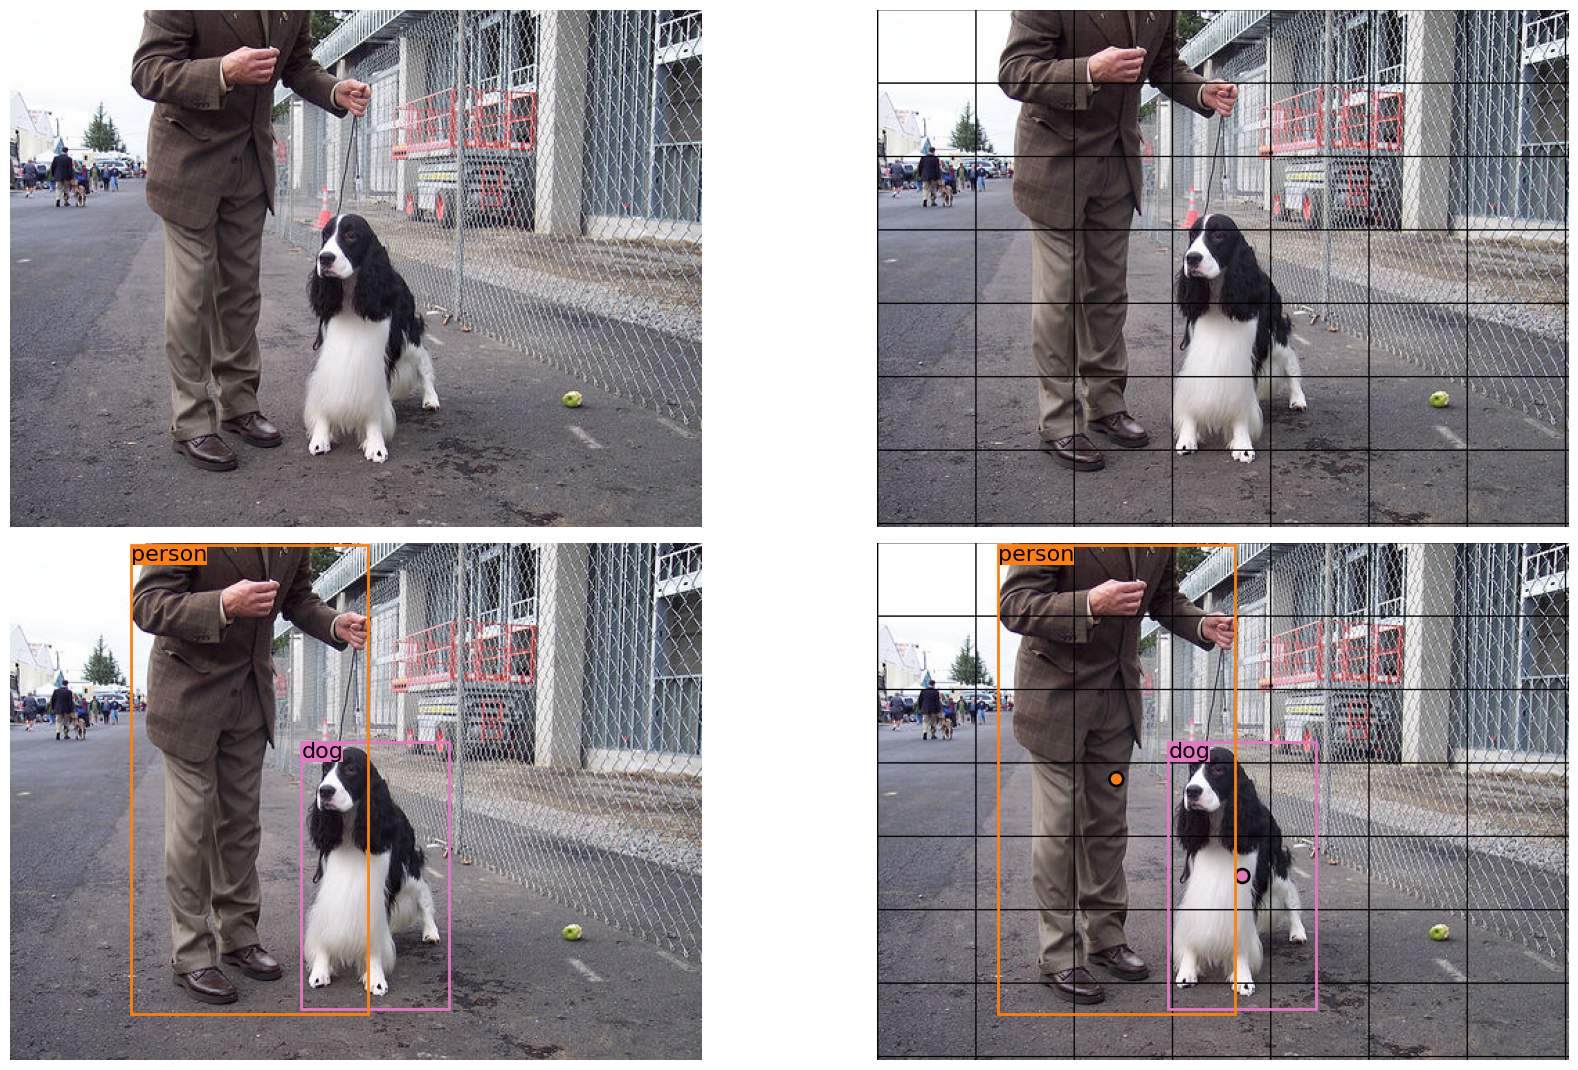

In [ ]:
import matplotlib.patches as patches

cmap = plt.get_cmap('tab20')

colors = dict([(category, cmap(i / num_classes)) for i, category in enumerate(reversed_categories)])

fig, ax = plt.subplots(2, 2, figsize=(19.2, 10.8))

img = train["images"]["001182"].copy()
H, W, _ = img.shape

dw, dh = int(img.shape[0] / 7), int(img.shape[1] / 7)
grid_color = [0,0,0]

for (row, col) in [(0, 1), (1, 1)]:
    img[:,::dh,:] = grid_color
    img[::dw,:,:] = grid_color
    ax[row][col].imshow(img)

for i in range(2):
    for j in range(2):
        if (i == 0 and j == 1) or (i == 1 and j == 1):
            ax[i][j].axis("off")
            continue
        ax[i][j].imshow(train["images"]["001182"])
        ax[i][j].axis("off")

for (row, col) in [(1, 0), (1, 1)]:
    for bbox, label in zip(train["bboxes"]["001182"], train["labels"]["001182"]):
        if (row, col) == (1, 1):
            circle = patches.Circle(((bbox[0] + (bbox[2] / 2)) * W, (bbox[1] + (bbox[3] / 2)) * H), radius=5, linewidth=2, edgecolor="black", facecolor=colors[label])
            ax[row][col].add_patch(circle)
        rect = patches.Rectangle((bbox[0] * W, bbox[1] * H), bbox[2] * W, bbox[3] * H, linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
        ax[row][col].text(bbox[0] * W, bbox[1] * H, reversed_categories[label], color="black", backgroundcolor='red', ha='left', va='top', fontsize=16, bbox=dict(facecolor=colors[label], edgecolor='none', pad=0, alpha=1))
        ax[row][col].add_patch(rect)

fig.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"YOLO_explanation"))
plt.show()